# Transfer Learning for EEGNet and Deep4Net


1. **EEGNet** (~3,748 parameters) - Ultra-compact, depthwise separable convolutions
2. **Deep4Net** (~286,354 parameters) - Deep hierarchical CNN

## 1. Import Libraries

In [1]:
import numpy as np
import scipy.io
import scipy.linalg
import matplotlib.pyplot as plt
import os
import copy
import warnings
warnings.filterwarnings('ignore')

import braindecode
from braindecode.models import EEGNet, Deep4Net
from braindecode.util import set_random_seeds

import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Braindecode version: {braindecode.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Braindecode version: 1.2.0
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Define Helper Functions

In [2]:
def load_bci_mat_file(filepath):
    mat_data = scipy.io.loadmat(filepath)
    data_struct = mat_data['data'][0]
    
    all_X, all_y, all_trials, session_info = [], [], [], []
    
    for session_idx, session in enumerate(data_struct):
        session_data = session[0][0]
        X = session_data['X']  # EEG data (samples x channels)
        fs = session_data['fs'].item() if session_data['fs'].ndim == 0 else session_data['fs'][0, 0]
        classes = session_data['classes']
        trial_field = session_data['trial']
        y_field = session_data['y']
        
        if trial_field.size > 0:
            all_X.append(X)
            all_y.append(y_field.flatten())
            all_trials.append(trial_field.flatten())
            session_info.append({
                'session_idx': session_idx,
                'fs': fs,
                'classes': [str(c.item()) for c in classes.flatten()],
                'n_trials': len(y_field.flatten())
            })
    
    return {
        'X': all_X,
        'y': np.concatenate(all_y) if all_y else np.array([]),
        'trials': np.concatenate(all_trials) if all_trials else np.array([]),
        'session_info': session_info,
        'fs': session_info[0]['fs'] if session_info else 250,
        'classes': session_info[0]['classes'] if session_info else []
    }


def extract_trial_windows(eeg_data, window_samples=1125):
    all_windows = []
    all_labels = []
    
    trial_idx = 0
    for session_idx, X_session in enumerate(eeg_data['X']):
        n_session_trials = eeg_data['session_info'][session_idx]['n_trials']
        trial_starts = eeg_data['trials'][trial_idx:trial_idx + n_session_trials]
        labels = eeg_data['y'][trial_idx:trial_idx + n_session_trials]
        
        for i, start in enumerate(trial_starts):
            end = min(start + window_samples, X_session.shape[0])
            if end - start >= window_samples:
                # Extract window and transpose to (channels, time)
                window = X_session[start:start + window_samples, :].T
                all_windows.append(window)
                all_labels.append(labels[i] - 1)  # Convert 1-4 to 0-3
        
        trial_idx += n_session_trials
    
    return np.array(all_windows), np.array(all_labels)


print("Data loading functions loaded!")

Data loading functions loaded!


## 3. Euclidean Alignment Implementation

Euclidean Alignment (EA) reduces inter-subject variability by aligning EEG data to a common reference.

In [3]:
def euclidean_alignment(X_trials):
    n_trials, n_channels, n_times = X_trials.shape
    
    # Compute covariance matrix for each trial
    covs = []
    for trial in X_trials:
        cov = np.cov(trial)
        covs.append(cov)
    
    # Compute mean covariance matrix
    R = np.mean(covs, axis=0)
    
    # Compute R^(-1/2) using matrix square root
    R_sqrt = scipy.linalg.sqrtm(R)
    R_inv_sqrt = np.linalg.inv(R_sqrt)
    
    # Handle numerical issues (ensure real values)
    R_inv_sqrt = np.real(R_inv_sqrt)
    
    # Align all trials: X_aligned = R^(-1/2) @ X
    X_aligned = np.array([R_inv_sqrt @ trial for trial in X_trials])
    
    return X_aligned


def euclidean_alignment_per_subject(subjects_data):
    aligned_data = {}
    
    for subj_id, (X, y) in subjects_data.items():
        print(f"  Applying EA to subject {subj_id}...")
        X_aligned = euclidean_alignment(X)
        aligned_data[subj_id] = (X_aligned, y)
    
    return aligned_data


print("Euclidean Alignment functions loaded!")

Euclidean Alignment functions loaded!


## 4. Training and Evaluation Functions

In [4]:
def train_model(model, X_train, y_train, epochs=50, lr=0.001, batch_size=32, weight_decay=0.01, verbose=True):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    X_tensor = torch.FloatTensor(X_train)
    y_tensor = torch.LongTensor(y_train)
    
    history = {'loss': [], 'accuracy': []}
    
    model.train()
    for epoch in range(epochs):
        # Shuffle data
        perm = torch.randperm(len(X_tensor))
        X_shuffled = X_tensor[perm]
        y_shuffled = y_tensor[perm]
        
        epoch_loss = 0.0
        correct = 0
        total = 0
        
        # Mini-batch training
        for i in range(0, len(X_tensor), batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        
        scheduler.step()
        avg_loss = epoch_loss / (len(X_tensor) // batch_size + 1)
        acc = correct / total
        history['loss'].append(avg_loss)
        history['accuracy'].append(acc)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {acc:.4f}")
    
    return history


def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test)
        outputs = model(X_tensor)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
    acc = accuracy_score(y_test, predicted.numpy())
    return acc, predicted.numpy(), probs.numpy()


def freeze_layers_by_pattern(model, patterns):
    frozen_count = 0
    trainable_count = 0
    
    for name, param in model.named_parameters():
        should_freeze = any(pattern in name for pattern in patterns)
        if should_freeze:
            param.requires_grad = False
            frozen_count += param.numel()
        else:
            trainable_count += param.numel()
    
    return frozen_count, trainable_count


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return total, trainable, frozen


print("Training functions loaded!")

Training functions loaded!


## 5. Load and Preprocess Data

In [5]:
set_random_seeds(seed=42, cuda=False)

data_dir = 'data'
window_samples = 1125  # 4.5 seconds at 250 Hz
n_chans = 25
n_outputs = 4
sfreq = 250

subjects_data = {}

print("Loading EEG data for all subjects...")
print("=" * 50)

for subj_id in range(1, 10):
    for suffix in ['E', 'T']:
        filename = f'A{subj_id:02d}{suffix}.mat'
        filepath = os.path.join(data_dir, f's{subj_id}', filename)
        if os.path.exists(filepath):
            eeg_data = load_bci_mat_file(filepath)
            if len(eeg_data['session_info']) > 0:
                X_trials, y_labels = extract_trial_windows(eeg_data, window_samples=window_samples)
                subjects_data[subj_id] = (X_trials, y_labels)
                print(f"Subject {subj_id} ({filename}): {len(X_trials)} trials, shape {X_trials.shape}")
                break

print("=" * 50)
print(f"Total subjects loaded: {len(subjects_data)}")

Loading EEG data for all subjects...
Subject 1 (A01E.mat): 288 trials, shape (288, 25, 1125)
Subject 2 (A02E.mat): 288 trials, shape (288, 25, 1125)
Subject 3 (A03E.mat): 288 trials, shape (288, 25, 1125)
Subject 4 (A04E.mat): 288 trials, shape (288, 25, 1125)
Subject 5 (A05E.mat): 288 trials, shape (288, 25, 1125)
Subject 6 (A06E.mat): 288 trials, shape (288, 25, 1125)
Subject 7 (A07E.mat): 288 trials, shape (288, 25, 1125)
Subject 8 (A08E.mat): 288 trials, shape (288, 25, 1125)
Subject 9 (A09E.mat): 288 trials, shape (288, 25, 1125)
Total subjects loaded: 9


## 6. Apply Euclidean Alignment

In [6]:
print("Applying Euclidean Alignment to each subject...")
print("=" * 50)

aligned_data = euclidean_alignment_per_subject(subjects_data)

print("=" * 50)
print("Euclidean Alignment complete!")

print("\nVerifying alignment effect on Subject 1:")
X_before = subjects_data[1][0]
X_after = aligned_data[1][0]

cov_before = np.mean([np.cov(trial) for trial in X_before[:10]], axis=0)
cov_after = np.mean([np.cov(trial) for trial in X_after[:10]], axis=0)

print(f"Mean covariance trace before EA: {np.trace(cov_before):.4f}")
print(f"Mean covariance trace after EA:  {np.trace(cov_after):.4f}")
print(f"(After EA, trace should be closer to n_channels={n_chans})")

Applying Euclidean Alignment to each subject...
  Applying EA to subject 1...
  Applying EA to subject 2...
  Applying EA to subject 3...
  Applying EA to subject 4...
  Applying EA to subject 5...
  Applying EA to subject 6...
  Applying EA to subject 7...
  Applying EA to subject 8...
  Applying EA to subject 9...
Euclidean Alignment complete!

Verifying alignment effect on Subject 1:
  Mean covariance trace before EA: 3831.0358
  Mean covariance trace after EA:  25.6388
  (After EA, trace should be closer to n_channels=25)


## 7. Prepare Cross-Subject Splits


In [7]:
# Source subjects: 2-9 (training)
source_subjects = list(range(2, 10))

# Target subject: 1 (testing - never seen)
target_subject = 1

X_source_list = [aligned_data[i][0] for i in source_subjects]
y_source_list = [aligned_data[i][1] for i in source_subjects]

X_source = np.concatenate(X_source_list, axis=0)
y_source = np.concatenate(y_source_list, axis=0)

X_target = aligned_data[target_subject][0]
y_target = aligned_data[target_subject][1]

X_target_ft, X_target_test, y_target_ft, y_target_test = train_test_split(
    X_target, y_target, test_size=0.7, random_state=42, stratify=y_target
)

X_s1_train, X_s1_test, y_s1_train, y_s1_test = train_test_split(
    X_target, y_target, test_size=0.3, random_state=42, stratify=y_target
)

print("Cross-Subject Data Split")
print("=" * 50)
print(f"Source subjects: {source_subjects}")
print(f"Target subject: {target_subject}")
print("-" * 50)
print(f"Source data shape: {X_source.shape}")
print(f"Source label distribution: {np.bincount(y_source + 1)}")
print("-" * 50)
print(f"Target fine-tune set: {X_target_ft.shape}")
print(f"Target test set: {X_target_test.shape}")
print(f"Subject-specific train: {X_s1_train.shape}")
print(f"Subject-specific test: {X_s1_test.shape}")

Cross-Subject Data Split
Source subjects: [2, 3, 4, 5, 6, 7, 8, 9]
Target subject: 1
--------------------------------------------------
Source data shape: (2304, 25, 1125)
Source label distribution: [  0 576 576 576 576]
--------------------------------------------------
Target fine-tune set: (86, 25, 1125)
Target test set: (202, 25, 1125)
Subject-specific train: (201, 25, 1125)
Subject-specific test: (87, 25, 1125)


---
# Part A: EEGNet 

## A1. Create EEGNet Model and Count Parameters

In [8]:
print("=" * 60)
print("EEGNet Model Architecture Analysis")
print("=" * 60)

model_eegnet = EEGNet(
    n_chans=n_chans,
    n_outputs=n_outputs,
    n_times=window_samples,
    sfreq=sfreq,
    final_conv_length='auto'
)

total_params, trainable_params, frozen_params = count_parameters(model_eegnet)
print(f"\nEEGNet Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Frozen: {frozen_params:,}")

print("\nModel layers:")
for name, module in model_eegnet.named_children():
    print(f"  {name}: {type(module).__name__}")

EEGNet Model Architecture Analysis

EEGNet Parameters:
  Total: 3,748
  Trainable: 3,748
  Frozen: 0

Model layers:
  ensuredims: Ensure4d
  dimshuffle: Rearrange
  conv_temporal: Conv2d
  bnorm_temporal: BatchNorm2d
  conv_spatial: ParametrizedConv2dWithConstraint
  bnorm_1: BatchNorm2d
  elu_1: ELU
  pool_1: AvgPool2d
  drop_1: Dropout
  conv_separable_depth: Conv2d
  conv_separable_point: Conv2d
  bnorm_2: BatchNorm2d
  elu_2: ELU
  pool_2: AvgPool2d
  drop_2: Dropout
  final_layer: Sequential


## A2. Experiment E1: EEGNet Subject-Specific Baseline



In [9]:
print("=" * 60)
print("Experiment E1: EEGNet Subject-Specific Baseline")
print("=" * 60)

print(f"Train: {X_s1_train.shape}, Test: {X_s1_test.shape}")

model_eegnet_baseline = EEGNet(
    n_chans=n_chans,
    n_outputs=n_outputs,
    n_times=window_samples,
    sfreq=sfreq,
    final_conv_length='auto'
)

print("\nTraining subject-specific EEGNet model...")
history_eegnet_baseline = train_model(
    model_eegnet_baseline, X_s1_train, y_s1_train,
    epochs=50, lr=0.001, batch_size=32
)

acc_eegnet_baseline, pred_eegnet_baseline, _ = evaluate_model(
    model_eegnet_baseline, X_s1_test, y_s1_test
)
print(f"\n>>> EEGNet Subject-Specific Test Accuracy: {acc_eegnet_baseline:.4f} ({acc_eegnet_baseline*100:.2f}%)")

Experiment E1: EEGNet Subject-Specific Baseline
Train: (201, 25, 1125), Test: (87, 25, 1125)

Training subject-specific EEGNet model...
Epoch 10/50, Loss: 0.7089, Train Acc: 0.8109
Epoch 20/50, Loss: 0.3238, Train Acc: 0.9502
Epoch 30/50, Loss: 0.2082, Train Acc: 0.9801
Epoch 40/50, Loss: 0.1721, Train Acc: 0.9801
Epoch 50/50, Loss: 0.1620, Train Acc: 0.9900

>>> EEGNet Subject-Specific Test Accuracy: 0.6207 (62.07%)


## A3. Experiment E2: EEGNet Pre-train on Source Subjects

In [10]:
print("=" * 60)
print("Experiment E2: EEGNet Pre-train on Subjects 2-9")
print("=" * 60)

model_eegnet_general = EEGNet(
    n_chans=n_chans,
    n_outputs=n_outputs,
    n_times=window_samples,
    sfreq=sfreq,
    final_conv_length='auto'
)

print(f"Source data: {X_source.shape[0]} trials from subjects {source_subjects}")
print("\nPre-training EEGNet general model...")

history_eegnet_pretrain = train_model(
    model_eegnet_general, X_source, y_source,
    epochs=60, lr=0.001, batch_size=32
)

print("\nPre-training complete!")

Experiment E2: EEGNet Pre-train on Subjects 2-9
Source data: 2304 trials from subjects [2, 3, 4, 5, 6, 7, 8, 9]

Pre-training EEGNet general model...
Epoch 10/60, Loss: 0.5290, Train Acc: 0.8108
Epoch 20/60, Loss: 0.4424, Train Acc: 0.8420
Epoch 30/60, Loss: 0.4041, Train Acc: 0.8581
Epoch 40/60, Loss: 0.3788, Train Acc: 0.8702
Epoch 50/60, Loss: 0.3628, Train Acc: 0.8746
Epoch 60/60, Loss: 0.3624, Train Acc: 0.8785

Pre-training complete!


## A4. Experiment E3: EEGNet Zero-Shot Evaluation

In [25]:
print("=" * 60)
print("Experiment E3: EEGNet Zero-Shot Cross-Subject Evaluation")
print("=" * 60)
print("Testing pre-trained EEGNet on Subject 1 (never seen during training)...")

acc_eegnet_zero_shot, pred_eegnet_zero_shot, _ = evaluate_model(
    model_eegnet_general, X_target_test, y_target_test
)

print(f"\n>>> EEGNet Zero-Shot Test Accuracy: {acc_eegnet_zero_shot:.4f} ({acc_eegnet_zero_shot*100:.2f}%)")

Experiment E3: EEGNet Zero-Shot Cross-Subject Evaluation
Testing pre-trained EEGNet on Subject 1 (never seen during training)...

>>> EEGNet Zero-Shot Test Accuracy: 0.6881 (68.81%)


## A5. Experiment E4: EEGNet Full Fine-Tuning

In [12]:
print("=" * 60)
print("Experiment E4: EEGNet Full Fine-Tuning (All Layers)")
print("=" * 60)

model_eegnet_finetuned = copy.deepcopy(model_eegnet_general)

print(f"Fine-tuning data: {X_target_ft.shape[0]} trials from Subject 1")
print("Fine-tuning ALL layers with lower learning rate...")

history_eegnet_finetune = train_model(
    model_eegnet_finetuned, X_target_ft, y_target_ft,
    epochs=20, lr=0.0001, batch_size=16
)

acc_eegnet_finetuned, pred_eegnet_finetuned, _ = evaluate_model(
    model_eegnet_finetuned, X_target_test, y_target_test
)

print(f"\n>>> EEGNet Fine-Tuned Test Accuracy: {acc_eegnet_finetuned:.4f} ({acc_eegnet_finetuned*100:.2f}%)")
print(f">>> Improvement over zero-shot: {(acc_eegnet_finetuned - acc_eegnet_zero_shot) / acc_eegnet_zero_shot * 100:.1f}%")

Experiment E4: EEGNet Full Fine-Tuning (All Layers)
Fine-tuning data: 86 trials from Subject 1
Fine-tuning ALL layers with lower learning rate...
Epoch 10/20, Loss: 0.5568, Train Acc: 0.7791
Epoch 20/20, Loss: 0.6176, Train Acc: 0.8023

>>> EEGNet Fine-Tuned Test Accuracy: 0.7624 (76.24%)
>>> Improvement over zero-shot: 10.8%


---
# Part B: Deep4Net

## B1. Create Deep4Net Model and Count Parameters

In [13]:
print("=" * 60)
print("Deep4Net Model Architecture Analysis")
print("=" * 60)

model_deep4 = Deep4Net(
    n_chans=n_chans,
    n_outputs=n_outputs,
    n_times=window_samples,
    sfreq=sfreq,
    final_conv_length='auto'
)

total_params, trainable_params, frozen_params = count_parameters(model_deep4)
print(f"\nDeep4Net Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Frozen: {frozen_params:,}")

print("\nModel layers:")
for name, module in model_deep4.named_children():
    print(f"  {name}: {type(module).__name__}")

Deep4Net Model Architecture Analysis

Deep4Net Parameters:
  Total: 286,354
  Trainable: 286,354
  Frozen: 0

Model layers:
  ensuredims: Ensure4d
  dimshuffle: Rearrange
  conv_time_spat: CombinedConv
  bnorm: BatchNorm2d
  conv_nonlin: ELU
  pool: MaxPool2d
  pool_nonlin: Identity
  drop_2: Dropout
  conv_2: Conv2d
  bnorm_2: BatchNorm2d
  nonlin_2: ELU
  pool_2: MaxPool2d
  pool_nonlin_2: Identity
  drop_3: Dropout
  conv_3: Conv2d
  bnorm_3: BatchNorm2d
  nonlin_3: ELU
  pool_3: MaxPool2d
  pool_nonlin_3: Identity
  drop_4: Dropout
  conv_4: Conv2d
  bnorm_4: BatchNorm2d
  nonlin_4: ELU
  pool_4: MaxPool2d
  pool_nonlin_4: Identity
  final_layer: Sequential


## B2. Experiment D1: Deep4Net Subject-Specific Baseline

In [14]:
print("=" * 60)
print("Experiment D1: Deep4Net Subject-Specific Baseline")
print("=" * 60)

print(f"Train: {X_s1_train.shape}, Test: {X_s1_test.shape}")

model_deep4_baseline = Deep4Net(
    n_chans=n_chans,
    n_outputs=n_outputs,
    n_times=window_samples,
    sfreq=sfreq,
    final_conv_length='auto'
)

print("\nTraining subject-specific Deep4Net model...")
history_deep4_baseline = train_model(
    model_deep4_baseline, X_s1_train, y_s1_train,
    epochs=80, lr=0.0005, batch_size=32
)

acc_deep4_baseline, pred_deep4_baseline, _ = evaluate_model(
    model_deep4_baseline, X_s1_test, y_s1_test
)
print(f"\n>>> Deep4Net Subject-Specific Test Accuracy: {acc_deep4_baseline:.4f} ({acc_deep4_baseline*100:.2f}%)")

Experiment D1: Deep4Net Subject-Specific Baseline
Train: (201, 25, 1125), Test: (87, 25, 1125)

Training subject-specific Deep4Net model...
Epoch 10/80, Loss: 0.7738, Train Acc: 0.6716
Epoch 20/80, Loss: 0.3474, Train Acc: 0.8856
Epoch 30/80, Loss: 0.1294, Train Acc: 0.9751
Epoch 40/80, Loss: 0.1448, Train Acc: 0.9403
Epoch 50/80, Loss: 0.0991, Train Acc: 0.9801
Epoch 60/80, Loss: 0.1415, Train Acc: 0.9502
Epoch 70/80, Loss: 0.0932, Train Acc: 0.9801
Epoch 80/80, Loss: 0.0813, Train Acc: 0.9751

>>> Deep4Net Subject-Specific Test Accuracy: 0.4483 (44.83%)


## B3. Experiment D2: Deep4Net Pre-train on Source Subjects

In [15]:
print("=" * 60)
print("Experiment D2: Deep4Net Pre-train on Subjects 2-9")
print("=" * 60)

model_deep4_general = Deep4Net(
    n_chans=n_chans,
    n_outputs=n_outputs,
    n_times=window_samples,
    sfreq=sfreq,
    final_conv_length='auto'
)

print(f"Source data: {X_source.shape[0]} trials from subjects {source_subjects}")
print("\nPre-training Deep4Net general model...")

history_deep4_pretrain = train_model(
    model_deep4_general, X_source, y_source,
    epochs=100, lr=0.0005, batch_size=32
)

print("\nPre-training complete!")

Experiment D2: Deep4Net Pre-train on Subjects 2-9
Source data: 2304 trials from subjects [2, 3, 4, 5, 6, 7, 8, 9]

Pre-training Deep4Net general model...
Epoch 10/100, Loss: 0.6353, Train Acc: 0.7578
Epoch 20/100, Loss: 0.4891, Train Acc: 0.8151
Epoch 30/100, Loss: 0.3959, Train Acc: 0.8559
Epoch 40/100, Loss: 0.3187, Train Acc: 0.8911
Epoch 50/100, Loss: 0.2678, Train Acc: 0.9076
Epoch 60/100, Loss: 0.2241, Train Acc: 0.9306
Epoch 70/100, Loss: 0.1753, Train Acc: 0.9536
Epoch 80/100, Loss: 0.1679, Train Acc: 0.9553
Epoch 90/100, Loss: 0.1450, Train Acc: 0.9627
Epoch 100/100, Loss: 0.1451, Train Acc: 0.9614

Pre-training complete!


## B4. Experiment D3: Deep4Net Zero-Shot Evaluation

In [26]:
print("=" * 60)
print("Experiment D3: Deep4Net Zero-Shot Cross-Subject Evaluation")
print("=" * 60)
print("Testing pre-trained Deep4Net on Subject 1 (never seen during training)...")

acc_deep4_zero_shot, pred_deep4_zero_shot, _ = evaluate_model(
    model_deep4_general, X_target_test, y_target_test
)

print(f"\n>>> Deep4Net Zero-Shot Test Accuracy: {acc_deep4_zero_shot:.4f} ({acc_deep4_zero_shot*100:.2f}%)")

Experiment D3: Deep4Net Zero-Shot Cross-Subject Evaluation
Testing pre-trained Deep4Net on Subject 1 (never seen during training)...

>>> Deep4Net Zero-Shot Test Accuracy: 0.7327 (73.27%)


## B5. Experiment D4: Deep4Net Full Fine-Tuning

In [17]:
print("=" * 60)
print("Experiment D4: Deep4Net Full Fine-Tuning (All Layers)")
print("=" * 60)

model_deep4_finetuned = copy.deepcopy(model_deep4_general)

print(f"Fine-tuning data: {X_target_ft.shape[0]} trials from Subject 1")
print("Fine-tuning ALL layers with lower learning rate...")

history_deep4_finetune = train_model(
    model_deep4_finetuned, X_target_ft, y_target_ft,
    epochs=40, lr=0.00005, batch_size=16
)

acc_deep4_finetuned, pred_deep4_finetuned, _ = evaluate_model(
    model_deep4_finetuned, X_target_test, y_target_test
)

print(f"\n>>> Deep4Net Fine-Tuned Test Accuracy: {acc_deep4_finetuned:.4f} ({acc_deep4_finetuned*100:.2f}%)")
print(f">>> Improvement over zero-shot: {(acc_deep4_finetuned - acc_deep4_zero_shot) / acc_deep4_zero_shot * 100:.1f}%")

Experiment D4: Deep4Net Full Fine-Tuning (All Layers)
Fine-tuning data: 86 trials from Subject 1
Fine-tuning ALL layers with lower learning rate...
Epoch 10/40, Loss: 0.2086, Train Acc: 0.9535
Epoch 20/40, Loss: 0.1724, Train Acc: 0.9302
Epoch 30/40, Loss: 0.1212, Train Acc: 0.9767
Epoch 40/40, Loss: 0.1530, Train Acc: 0.9535

>>> Deep4Net Fine-Tuned Test Accuracy: 0.8069 (80.69%)
>>> Improvement over zero-shot: 10.1%


## B6. Experiment D5: Deep4Net Layer Freezing Strategy

In [18]:
print("=" * 60)
print("Experiment D5: Deep4Net Layer Freezing Strategy")
print("=" * 60)

model_deep4_frozen = copy.deepcopy(model_deep4_general)

# Freeze early layers (conv_time, conv_spat, bnorm)
freeze_patterns = ['conv_time', 'conv_spat', 'bnorm']

print(f"Freezing layers matching patterns: {freeze_patterns}")
frozen_count, trainable_count = freeze_layers_by_pattern(model_deep4_frozen, freeze_patterns)

print(f"\nFrozen parameters: {frozen_count:,}")
print(f"Trainable parameters: {trainable_count:,}")
print(f"Total parameters: {frozen_count + trainable_count:,}")
print(f"Frozen ratio: {frozen_count / (frozen_count + trainable_count) * 100:.1f}%")

# Fine-tune with frozen layers (higher LR since only training later layers)
print("\nFine-tuning with frozen early layers...")

history_deep4_frozen = train_model(
    model_deep4_frozen, X_target_ft, y_target_ft,
    epochs=40, lr=0.0001, batch_size=16
)

acc_deep4_frozen, pred_deep4_frozen, _ = evaluate_model(
    model_deep4_frozen, X_target_test, y_target_test
)

print(f"\n>>> Deep4Net Frozen Layers Test Accuracy: {acc_deep4_frozen:.4f} ({acc_deep4_frozen*100:.2f}%)")

Experiment D5: Deep4Net Layer Freezing Strategy
Freezing layers matching patterns: ['conv_time', 'conv_spat', 'bnorm']

Frozen parameters: 16,650
Trainable parameters: 269,704
Total parameters: 286,354
Frozen ratio: 5.8%

Fine-tuning with frozen early layers...
Epoch 10/40, Loss: 0.1924, Train Acc: 0.9186
Epoch 20/40, Loss: 0.1590, Train Acc: 0.9767
Epoch 30/40, Loss: 0.1221, Train Acc: 0.9767
Epoch 40/40, Loss: 0.0762, Train Acc: 0.9884

>>> Deep4Net Frozen Layers Test Accuracy: 0.7673 (76.73%)


---
# Part C: Results Summary and Visualization

## C1. Combined Results Table

In [27]:
print("=" * 80)
print("TRANSFER LEARNING RESULTS SUMMARY - ALL MODELS")
print("=" * 80)

# Reference: ShallowFBCSPNet results from previous experiments
acc_shallow_baseline = 0.6437
acc_shallow_zero_shot = 0.7426
acc_shallow_finetuned = 0.7970
acc_shallow_frozen = 0.7772

print(f"\n{'Model':<20} {'Strategy':<30} {'Accuracy':>12} {'vs Baseline':>15}")
print("-" * 80)

# EEGNet results
eegnet_results = [
    ('EEGNet (3.7K params)', 'Subject-Specific', acc_eegnet_baseline),
    ('EEGNet (3.7K params)', 'Zero-Shot (no adaptation)', acc_eegnet_zero_shot),
    ('EEGNet (3.7K params)', 'Full Fine-Tuning', acc_eegnet_finetuned),
]

# Deep4Net results
deep4_results = [
    ('Deep4Net (286K params)', 'Subject-Specific', acc_deep4_baseline),
    ('Deep4Net (286K params)', 'Zero-Shot (no adaptation)', acc_deep4_zero_shot),
    ('Deep4Net (286K params)', 'Full Fine-Tuning', acc_deep4_finetuned),
    ('Deep4Net (286K params)', 'Layer Freezing', acc_deep4_frozen),
]

# ShallowFBCSPNet results 
shallow_results = [
    ('ShallowFBCSPNet (52K params)', 'Subject-Specific', acc_shallow_baseline),
    ('ShallowFBCSPNet (52K params)', 'Zero-Shot (no adaptation)', acc_shallow_zero_shot),
    ('ShallowFBCSPNet (52K params)', 'Full Fine-Tuning', acc_shallow_finetuned),
    ('ShallowFBCSPNet (52K params)', 'Layer Freezing', acc_shallow_frozen),
]

all_results = eegnet_results + deep4_results + shallow_results

best_acc = max(r[2] for r in all_results)

for model, strategy, acc in all_results:
    baseline = acc_eegnet_baseline if 'EEGNet' in model else (acc_deep4_baseline if 'Deep4Net' in model else acc_shallow_baseline)
    diff = (acc - baseline) / baseline * 100
    marker = " <-- BEST" if acc == best_acc else ""
    print(f"{model:<20} {strategy:<30} {acc:>11.2%} {diff:>14.1f}%{marker}")


TRANSFER LEARNING RESULTS SUMMARY - ALL MODELS

Model                Strategy                           Accuracy     vs Baseline
--------------------------------------------------------------------------------
EEGNet (3.7K params) Subject-Specific                    62.07%            0.0%
EEGNet (3.7K params) Zero-Shot (no adaptation)           68.81%           10.9%
EEGNet (3.7K params) Full Fine-Tuning                    76.24%           22.8%
Deep4Net (286K params) Subject-Specific                    44.83%            0.0%
Deep4Net (286K params) Zero-Shot (no adaptation)           73.27%           63.4%
Deep4Net (286K params) Full Fine-Tuning                    80.69%           80.0% <-- BEST
Deep4Net (286K params) Layer Freezing                      76.73%           71.2%
ShallowFBCSPNet (52K params) Subject-Specific                    64.37%            0.0%
ShallowFBCSPNet (52K params) Zero-Shot (no adaptation)           74.26%           15.4%
ShallowFBCSPNet (52K params) Full Fin

## C2. Model Comparison Bar Chart

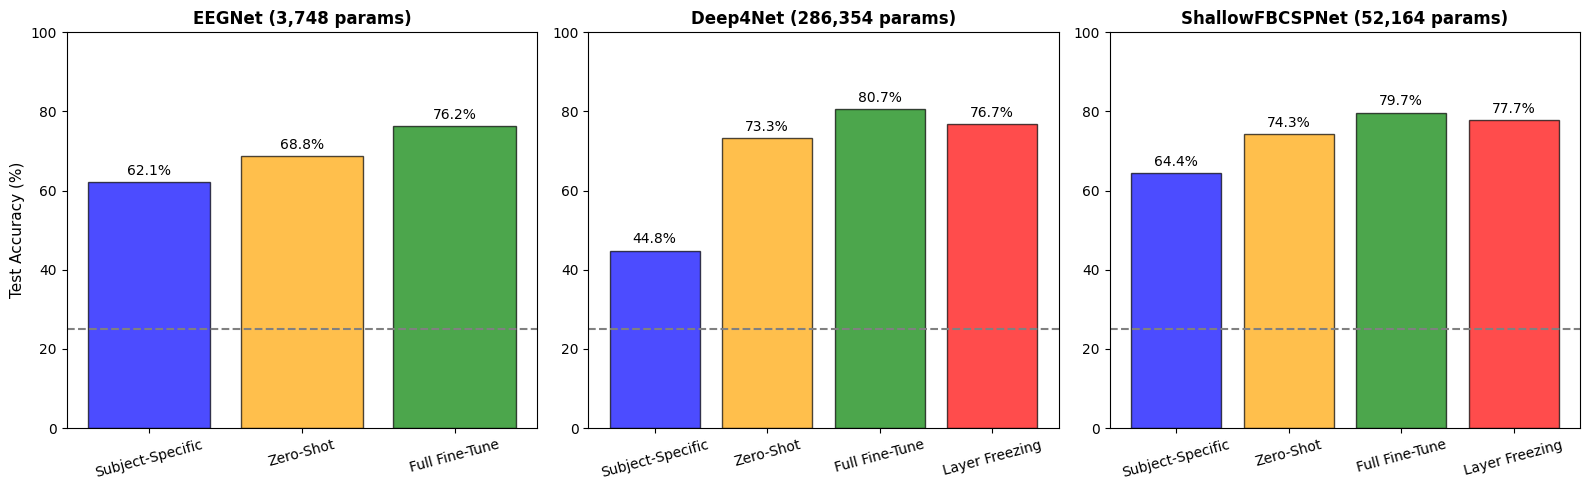


Saved: transfer_learning_all_models_comparison.png


In [20]:
# Bar chart comparison across all models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# EEGNet
strategies_eegnet = ['Subject-Specific', 'Zero-Shot', 'Full Fine-Tune']
accs_eegnet = [acc_eegnet_baseline, acc_eegnet_zero_shot, acc_eegnet_finetuned]
colors_eegnet = ['blue', 'orange', 'green']

bars1 = axes[0].bar(strategies_eegnet, [a * 100 for a in accs_eegnet], color=colors_eegnet, alpha=0.7, edgecolor='black')
axes[0].set_title('EEGNet (3,748 params)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].axhline(y=25, color='gray', linestyle='--', linewidth=1.5, label='Random (25%)')
axes[0].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars1, accs_eegnet):
    axes[0].annotate(f'{acc*100:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

# Deep4Net
strategies_deep4 = ['Subject-Specific', 'Zero-Shot', 'Full Fine-Tune', 'Layer Freezing']
accs_deep4 = [acc_deep4_baseline, acc_deep4_zero_shot, acc_deep4_finetuned, acc_deep4_frozen]
colors_deep4 = ['blue', 'orange', 'green', 'red']

bars2 = axes[1].bar(strategies_deep4, [a * 100 for a in accs_deep4], color=colors_deep4, alpha=0.7, edgecolor='black')
axes[1].set_title('Deep4Net (286,354 params)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].axhline(y=25, color='gray', linestyle='--', linewidth=1.5, label='Random (25%)')
axes[1].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars2, accs_deep4):
    axes[1].annotate(f'{acc*100:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

# ShallowFBCSPNet (reference)
strategies_shallow = ['Subject-Specific', 'Zero-Shot', 'Full Fine-Tune', 'Layer Freezing']
accs_shallow = [acc_shallow_baseline, acc_shallow_zero_shot, acc_shallow_finetuned, acc_shallow_frozen]
colors_shallow = ['blue', 'orange', 'green', 'red']

bars3 = axes[2].bar(strategies_shallow, [a * 100 for a in accs_shallow], color=colors_shallow, alpha=0.7, edgecolor='black')
axes[2].set_title('ShallowFBCSPNet (52,164 params)', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 100)
axes[2].axhline(y=25, color='gray', linestyle='--', linewidth=1.5, label='Random (25%)')
axes[2].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars3, accs_shallow):
    axes[2].annotate(f'{acc*100:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('transfer_learning_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: transfer_learning_all_models_comparison.png")

## C3. Training Curves

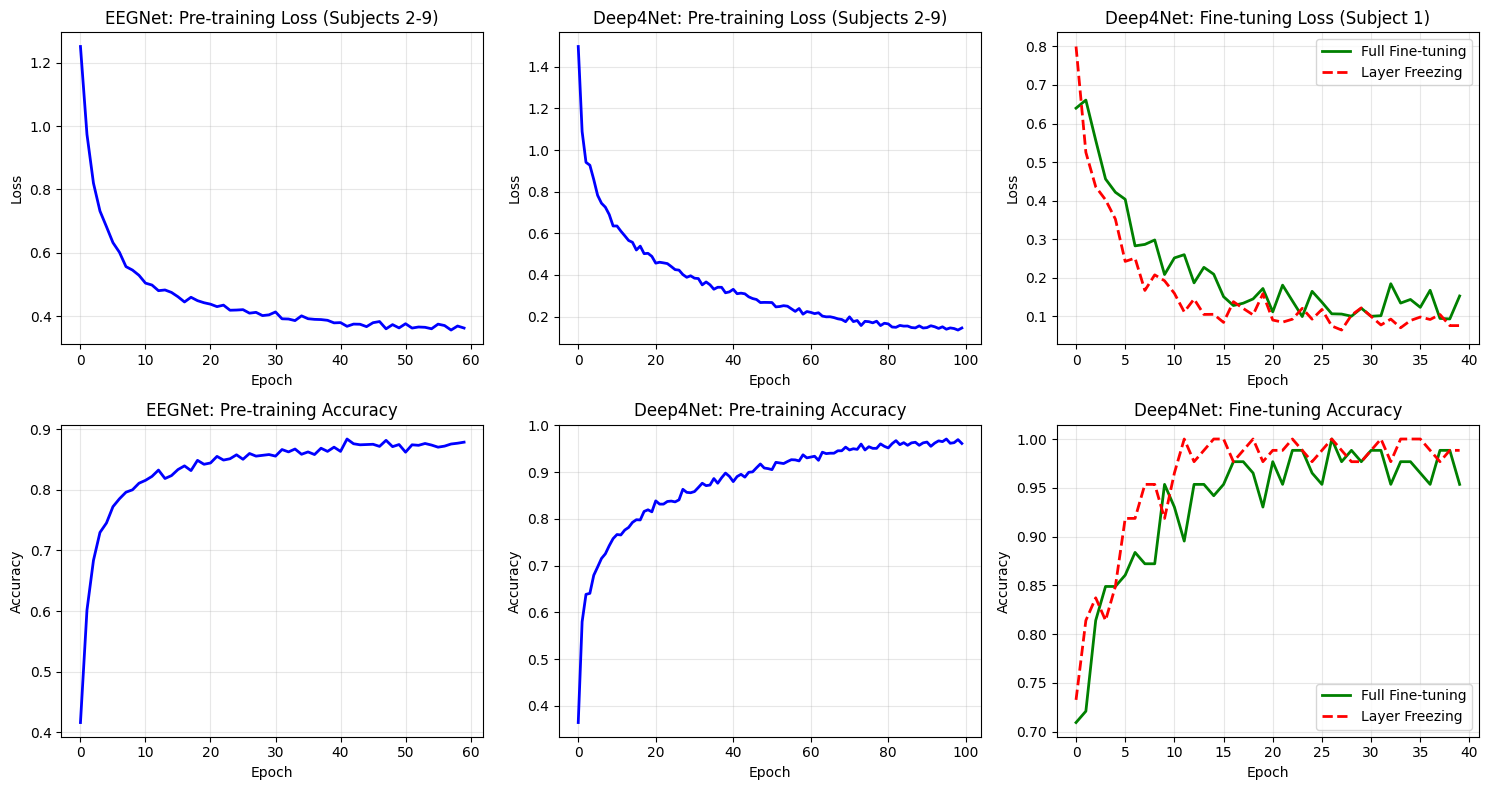


Saved: transfer_learning_training_curves.png


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# EEGNet pre-training
axes[0, 0].plot(history_eegnet_pretrain['loss'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('EEGNet: Pre-training Loss (Subjects 2-9)')
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(history_eegnet_pretrain['accuracy'], 'b-', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('EEGNet: Pre-training Accuracy')
axes[1, 0].grid(True, alpha=0.3)

# Deep4Net pre-training
axes[0, 1].plot(history_deep4_pretrain['loss'], 'b-', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Deep4Net: Pre-training Loss (Subjects 2-9)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].plot(history_deep4_pretrain['accuracy'], 'b-', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Deep4Net: Pre-training Accuracy')
axes[1, 1].grid(True, alpha=0.3)

# Fine-tuning comparison (Deep4Net)
axes[0, 2].plot(history_deep4_finetune['loss'], 'g-', linewidth=2, label='Full Fine-tuning')
axes[0, 2].plot(history_deep4_frozen['loss'], 'r--', linewidth=2, label='Layer Freezing')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].set_title('Deep4Net: Fine-tuning Loss (Subject 1)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

axes[1, 2].plot(history_deep4_finetune['accuracy'], 'g-', linewidth=2, label='Full Fine-tuning')
axes[1, 2].plot(history_deep4_frozen['accuracy'], 'r--', linewidth=2, label='Layer Freezing')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Accuracy')
axes[1, 2].set_title('Deep4Net: Fine-tuning Accuracy')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transfer_learning_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: transfer_learning_training_curves.png")

## C4. Confusion Matrices

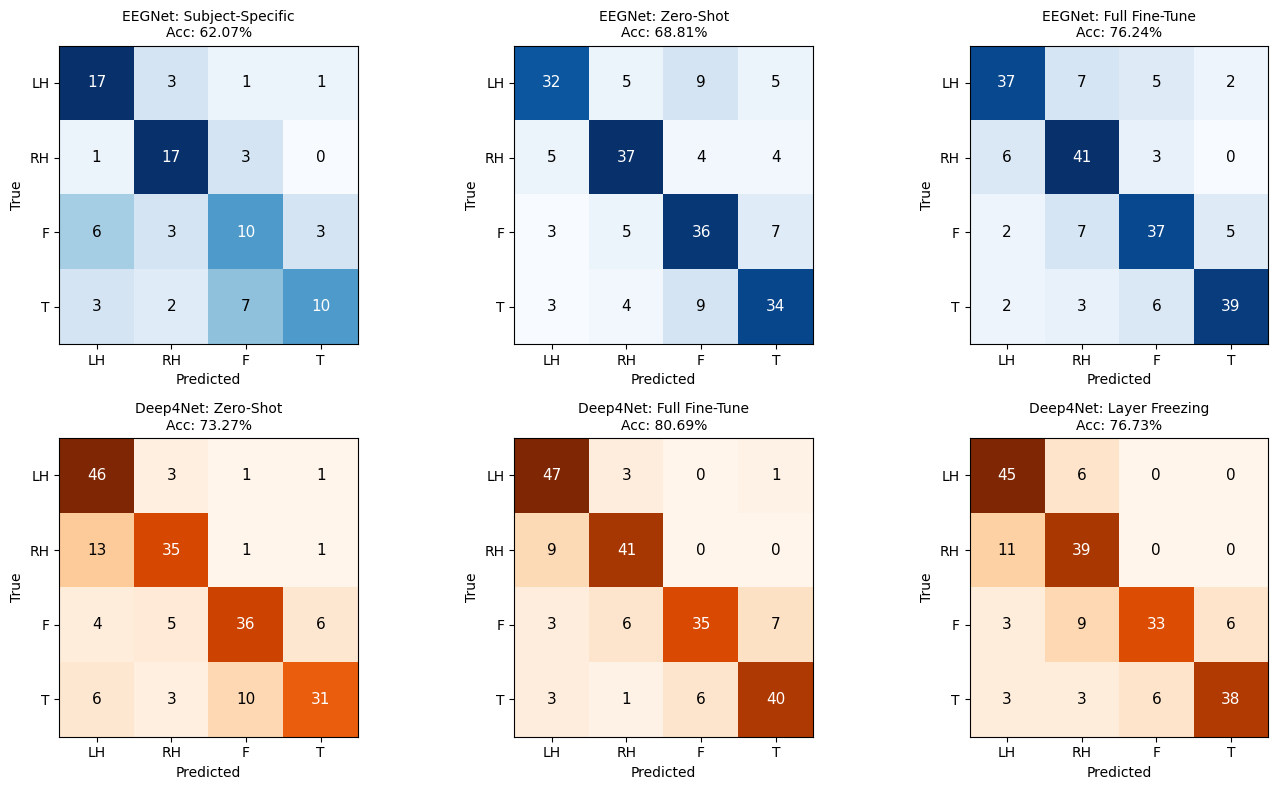


Saved: transfer_learning_confusion_matrices.png


In [22]:
class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
short_names = ['LH', 'RH', 'F', 'T']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# EEGNet results
eegnet_predictions = [
    ('EEGNet: Subject-Specific', pred_eegnet_baseline, y_s1_test),
    ('EEGNet: Zero-Shot', pred_eegnet_zero_shot, y_target_test),
    ('EEGNet: Full Fine-Tune', pred_eegnet_finetuned, y_target_test),
]

for idx, (name, pred, true) in enumerate(eegnet_predictions):
    cm = confusion_matrix(true, pred)
    acc = accuracy_score(true, pred)
    
    im = axes[0, idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[0, idx].set_title(f'{name}\nAcc: {acc:.2%}', fontsize=10)
    axes[0, idx].set_xticks(range(4))
    axes[0, idx].set_yticks(range(4))
    axes[0, idx].set_xticklabels(short_names)
    axes[0, idx].set_yticklabels(short_names)
    axes[0, idx].set_xlabel('Predicted')
    axes[0, idx].set_ylabel('True')
    
    for i in range(4):
        for j in range(4):
            axes[0, idx].text(j, i, cm[i, j], ha='center', va='center',
                             color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=11)

# Deep4Net results
deep4_predictions = [
    ('Deep4Net: Zero-Shot', pred_deep4_zero_shot, y_target_test),
    ('Deep4Net: Full Fine-Tune', pred_deep4_finetuned, y_target_test),
    ('Deep4Net: Layer Freezing', pred_deep4_frozen, y_target_test),
]

for idx, (name, pred, true) in enumerate(deep4_predictions):
    cm = confusion_matrix(true, pred)
    acc = accuracy_score(true, pred)
    
    im = axes[1, idx].imshow(cm, interpolation='nearest', cmap='Oranges')
    axes[1, idx].set_title(f'{name}\nAcc: {acc:.2%}', fontsize=10)
    axes[1, idx].set_xticks(range(4))
    axes[1, idx].set_yticks(range(4))
    axes[1, idx].set_xticklabels(short_names)
    axes[1, idx].set_yticklabels(short_names)
    axes[1, idx].set_xlabel('Predicted')
    axes[1, idx].set_ylabel('True')
    
    for i in range(4):
        for j in range(4):
            axes[1, idx].text(j, i, cm[i, j], ha='center', va='center',
                             color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=11)

plt.tight_layout()
plt.savefig('transfer_learning_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: transfer_learning_confusion_matrices.png")